In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import random
import time

In [2]:
df = pd.read_csv("OpenDengue_Spatial_Malaysia.csv")
df.head()

,adm_0_name,adm_1_name,adm_2_name,full_name,ISO_A0,FAO_GAUL_code,RNE_iso_code,IBGE_code,calendar_start_date,calendar_end_date,Year,dengue_total,case_definition_standardised,S_res,T_res,UUID,region
0,MALAYSIA,NaN,NaN,MALAYSIA,MYS,153,MYS,NaN,1974-01-01,1974-12-31,1974,2200,Total,Admin0,Year,TYCHO-ALL-19242017-SV_DF01-00,WPRO
1,MALAYSIA,NaN,NaN,MALAYSIA,MYS,153,MYS,NaN,1975-01-01,1975-12-31,1975,830,Total,Admin0,Year,TYCHO-ALL-19242017-SV_DF01-00,WPRO
2,MALAYSIA,NaN,NaN,MALAYSIA,MYS,153,MYS,NaN,1990-01-01,1990-12-31,1990,4880,Total,Admin0,Year,TYCHO-ALL-19242017-SV_DF01-00,WPRO
3,MALAYSIA,NaN,NaN,MALAYSIA,MYS,153,MYS,NaN,1991-01-01,1991-12-31,1991,6628,Total,Admin0,Year,TYCHO-ALL-19242017-SV_DF01-00,WPRO
4,MALAYSIA,NaN,NaN,MALAYSIA,MYS,153,MYS,NaN,1992-01-01,1992-12-31,1992,5473,Total,Admin0,Year,TYCHO-ALL-19242017-SV_DF01-00,WPRO


In [3]:
# Rename columns
df_renamed = df.rename(columns={
    'adm_0_name': 'country',
    'adm_1_name': 'state',
    'adm_2_name': 'district',
    'full_name': 'location_full',
    'calendar_start_date': 'period_start',
    'calendar_end_date': 'period_end',
    'Year': 'year',
    'dengue_total': 'dengue_cases',
    'case_definition_standardised': 'case_type'
})

# Drop unnecessary columns
columns_to_drop = [
    'ISO_A0', 'FAO_GAUL_code', 'RNE_iso_code', 'IBGE_code', 'UUID', 'region'
]

df_clean = df_renamed.drop(columns=columns_to_drop)
df_clean = df_clean[df_clean["year"] >= 2001]

# Display cleaned column names
df_clean.columns.tolist()

['country',
 'state',
 'district',
 'location_full',
 'period_start',
 'period_end',
 'year',
 'dengue_cases',
 'case_type',
 'S_res',
 'T_res']

In [4]:
df_clean.head()

,country,state,district,location_full,period_start,period_end,year,dengue_cases,case_type,S_res,T_res
753,MALAYSIA,SARAWAK,NaN,"MALAYSIA, SARAWAK",2001-01-01,2001-01-31,2001,52,Total,Admin1,Month
754,MALAYSIA,SELANGOR,NaN,"MALAYSIA, SELANGOR",2001-01-01,2001-01-31,2001,67,Total,Admin1,Month
755,MALAYSIA,JOHOR,NaN,"MALAYSIA, JOHOR",2001-01-01,2001-01-31,2001,114,Total,Admin1,Month
756,MALAYSIA,KELANTAN,NaN,"MALAYSIA, KELANTAN",2001-01-01,2001-01-31,2001,107,Total,Admin1,Month
757,MALAYSIA,NEGERI SEMBILAN,NaN,"MALAYSIA, NEGERI SEMBILAN",2001-01-01,2001-01-31,2001,190,Total,Admin1,Month


In [5]:
df_clean.describe(include="all")

,country,state,district,location_full,period_start,period_end,year,dengue_cases,case_type,S_res,T_res
count,1973,1328,0.0,1973,1973,1973,1973.000000,1973.000000,1973,1973,1973
unique,1,17,NaN,18,764,764,NaN,NaN,2,2,3
top,MALAYSIA,SELANGOR,NaN,MALAYSIA,2010-01-01,2010-12-31,NaN,NaN,Total,Admin1,Month
freq,1973,131,NaN,645,25,25,NaN,NaN,1668,1328,1176
mean,NaN,NaN,NaN,NaN,NaN,NaN,2009.767359,1256.134313,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,6.212931,5013.478600,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,2001.000000,1.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2005.000000,109.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2009.000000,302.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2015.000000,1253.000000,NaN,NaN,NaN


In [6]:
df = df_clean.drop(columns=["district"])
df.head()

,country,state,location_full,period_start,period_end,year,dengue_cases,case_type,S_res,T_res
753,MALAYSIA,SARAWAK,"MALAYSIA, SARAWAK",2001-01-01,2001-01-31,2001,52,Total,Admin1,Month
754,MALAYSIA,SELANGOR,"MALAYSIA, SELANGOR",2001-01-01,2001-01-31,2001,67,Total,Admin1,Month
755,MALAYSIA,JOHOR,"MALAYSIA, JOHOR",2001-01-01,2001-01-31,2001,114,Total,Admin1,Month
756,MALAYSIA,KELANTAN,"MALAYSIA, KELANTAN",2001-01-01,2001-01-31,2001,107,Total,Admin1,Month
757,MALAYSIA,NEGERI SEMBILAN,"MALAYSIA, NEGERI SEMBILAN",2001-01-01,2001-01-31,2001,190,Total,Admin1,Month


In [7]:
print(df['state'].unique())
print(df['case_type'].unique())
print(df['S_res'].unique())
print(df['T_res'].unique())

['SARAWAK' 'SELANGOR' 'JOHOR' 'KELANTAN' 'NEGERI SEMBILAN' 'PAHANG'
 'PERAK' 'PERLIS' 'PULAU PINANG' 'SABAH' nan 'MELAKA' 'KUALA LUMPUR'
 'TERENGGANU' 'KEDAH' 'LABUAN' 'W.P. KUALA LUMPUR' 'W.P. LABUAN']
['Total' 'Confirmed']
['Admin1' 'Admin0']
['Month' 'Year' 'Week']


In [8]:
df['S_res'] = df['S_res'].replace({
    'Admin0': 'National',
    'Admin1': 'State'
})
df['state'] = df['state'].str.strip().str.replace('W.P. ', '', regex=False)

print(df['state'].unique())

['SARAWAK' 'SELANGOR' 'JOHOR' 'KELANTAN' 'NEGERI SEMBILAN' 'PAHANG'
 'PERAK' 'PERLIS' 'PULAU PINANG' 'SABAH' nan 'MELAKA' 'KUALA LUMPUR'
 'TERENGGANU' 'KEDAH' 'LABUAN']


In [9]:
df.head()

,country,state,location_full,period_start,period_end,year,dengue_cases,case_type,S_res,T_res
753,MALAYSIA,SARAWAK,"MALAYSIA, SARAWAK",2001-01-01,2001-01-31,2001,52,Total,State,Month
754,MALAYSIA,SELANGOR,"MALAYSIA, SELANGOR",2001-01-01,2001-01-31,2001,67,Total,State,Month
755,MALAYSIA,JOHOR,"MALAYSIA, JOHOR",2001-01-01,2001-01-31,2001,114,Total,State,Month
756,MALAYSIA,KELANTAN,"MALAYSIA, KELANTAN",2001-01-01,2001-01-31,2001,107,Total,State,Month
757,MALAYSIA,NEGERI SEMBILAN,"MALAYSIA, NEGERI SEMBILAN",2001-01-01,2001-01-31,2001,190,Total,State,Month


In [10]:
# Filter for monthly data only
weekly_df = df[df['T_res'] == 'Week'].copy()

# Convert to datetime if not already
weekly_df['period_start'] = pd.to_datetime(weekly_df['period_start'])

# Group by period_start and count unique states for each month
weekly_counts = weekly_df.groupby('period_start').min()
weekly_counts

,country,state,location_full,period_end,year,dengue_cases,case_type,S_res,T_res
period_start,,,,,,,,,
2011-01-02,MALAYSIA,NaN,MALAYSIA,2011-01-08,2011,520,Total,National,Week
2011-01-09,MALAYSIA,NaN,MALAYSIA,2011-01-15,2011,597,Total,National,Week
2011-01-16,MALAYSIA,NaN,MALAYSIA,2011-01-22,2011,490,Total,National,Week
2011-01-23,MALAYSIA,NaN,MALAYSIA,2011-01-29,2011,494,Total,National,Week
2011-01-30,MALAYSIA,NaN,MALAYSIA,2011-02-05,2011,371,Total,National,Week
...,...,...,...,...,...,...,...,...,...
2022-11-27,MALAYSIA,NaN,MALAYSIA,2022-12-03,2022,1720,Total,National,Week
2022-12-04,MALAYSIA,NaN,MALAYSIA,2022-12-10,2022,1937,Total,National,Week
2022-12-11,MALAYSIA,NaN,MALAYSIA,2022-12-17,2022,1879,Total,National,Week


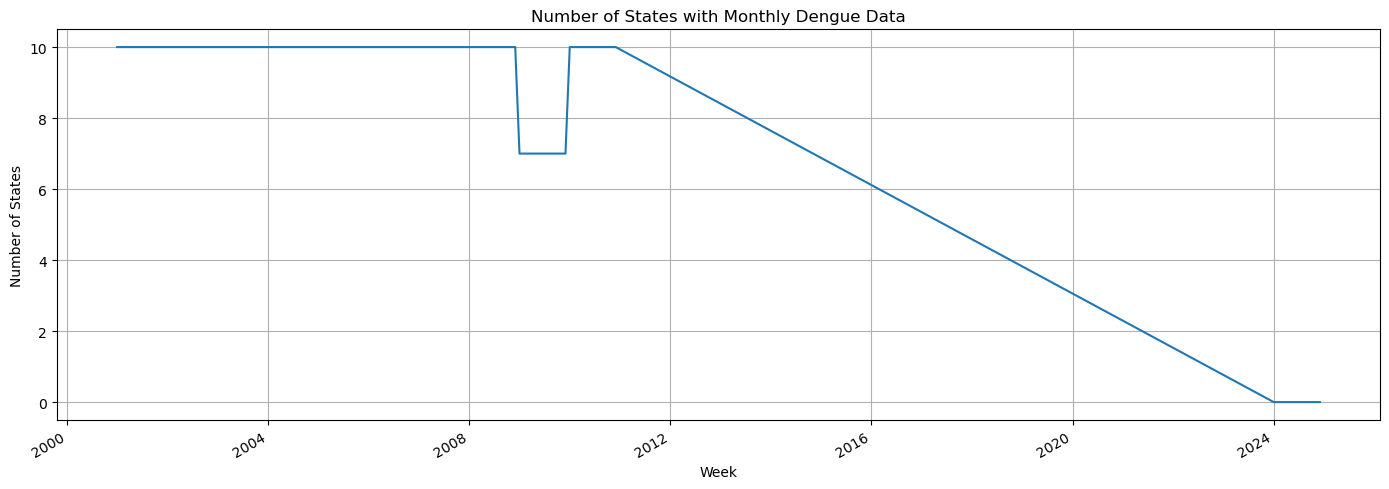

In [11]:
# Filter for monthly data only
weekly_df = df[df['T_res'] == 'Month'].copy()

# Convert to datetime if not already
weekly_df['period_start'] = pd.to_datetime(weekly_df['period_start'])

# Group by period_start and count unique states for each month
weekly_counts = weekly_df.groupby('period_start')['state'].nunique()

# Plot the time series
plt.figure(figsize=(14, 5))
weekly_counts.plot()
plt.title('Number of States with Monthly Dengue Data')
plt.ylabel('Number of States')
plt.xlabel('Week')
plt.grid(True)
plt.tight_layout()
plt.show()


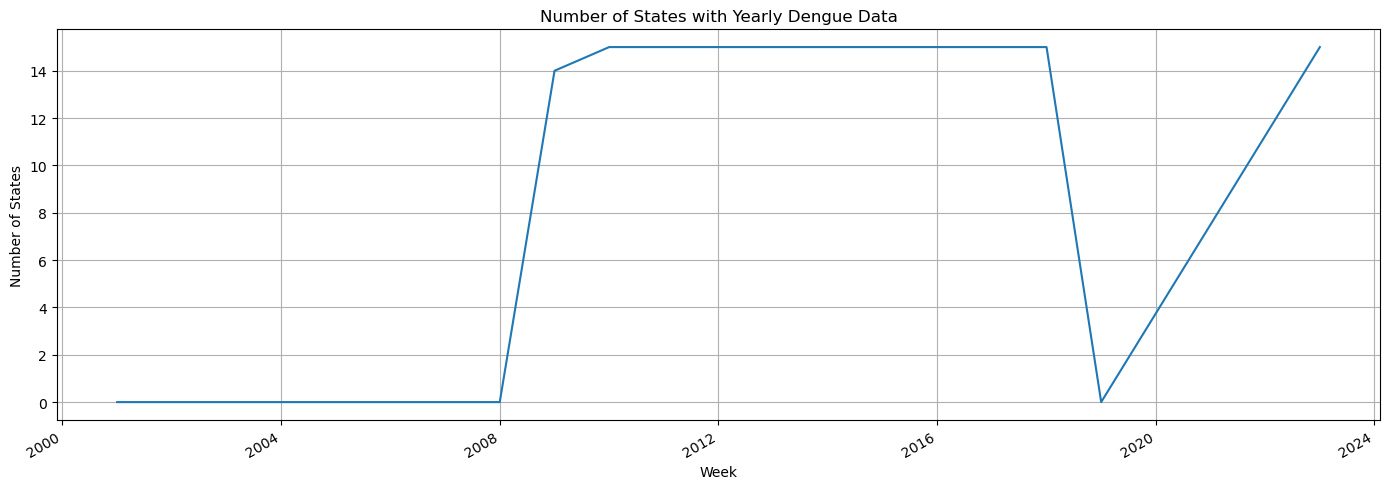

In [12]:
# Filter for annual data only
weekly_df = df[df['T_res'] == 'Year'].copy()

# Convert to datetime if not already
weekly_df['period_start'] = pd.to_datetime(weekly_df['period_start'])

# Group by period_start and count unique states for each year
weekly_counts = weekly_df.groupby('period_start')['state'].nunique()

# Plot the time series
plt.figure(figsize=(14, 5))
weekly_counts.plot()
plt.title('Number of States with Yearly Dengue Data')
plt.ylabel('Number of States')
plt.xlabel('Week')
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
df[df['case_type'] == 'Confirmed']

,country,state,location_full,period_start,period_end,year,dengue_cases,case_type,S_res,T_res
1728,MALAYSIA,PERAK,"MALAYSIA, PERAK",2009-01-01,2009-12-31,2009,2734,Confirmed,State,Year
1729,MALAYSIA,PAHANG,"MALAYSIA, PAHANG",2009-01-01,2009-12-31,2009,907,Confirmed,State,Year
1730,MALAYSIA,MELAKA,"MALAYSIA, MELAKA",2009-01-01,2009-12-31,2009,769,Confirmed,State,Year
1731,MALAYSIA,NEGERI SEMBILAN,"MALAYSIA, NEGERI SEMBILAN",2009-01-01,2009-12-31,2009,1057,Confirmed,State,Year
1732,MALAYSIA,PERLIS,"MALAYSIA, PERLIS",2009-01-01,2009-12-31,2009,191,Confirmed,State,Year
...,...,...,...,...,...,...,...,...,...,...
2774,MALAYSIA,NEGERI SEMBILAN,"MALAYSIA, NEGERI SEMBILAN",2013-01-01,2013-12-31,2013,1198,Confirmed,State,Year
2775,MALAYSIA,PERAK,"MALAYSIA, PERAK",2013-01-01,2013-12-31,2013,2519,Confirmed,State,Year
2776,MALAYSIA,SELANGOR,"MALAYSIA, SELANGOR",2013-01-01,2013-12-31,2013,23852,Confirmed,State,Year
2777,MALAYSIA,PAHANG,"MALAYSIA, PAHANG",2013-01-01,2013-12-31,2013,725,Confirmed,State,Year


In [14]:
def query_nasa_power(start, end, lat, lon):
    base_url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "start": start.replace('-', ''),
        "end": end.replace('-', ''),
        "latitude": lat,
        "longitude": lon,
        "parameters": "T2M,PRECTOTCORR,RH2M",
        "community": "AG",
        "format": "JSON"
    }
    response = requests.get(base_url, params=params)
    data = response.json()
    
    try:
        records = data['properties']['parameter']
        
        # Convert each date to datetime with noon (12:00) time
        df = pd.DataFrame({
            pd.to_datetime(date, format="%Y%m%d").replace(hour=12): {
                "T2M": records["T2M"].get(date),
                "PRECTOTCORR": records["PRECTOTCORR"].get(date),
                "RH2M": records["RH2M"].get(date)
            }
            for date in records["T2M"]
        }).T

        df = df.astype(float)
        return df

    except Exception as e:
        print(f"Error: {e}")
        return pd.DataFrame()


In [15]:
from functools import lru_cache

@lru_cache(maxsize=10000)
def cached_query(start, end, lat, lon):
    return query_nasa_power(start, end, lat, lon)


In [16]:
def generate_random_coords(bounds, n=30):
    points = []
    for _ in range(n):
        lat = random.uniform(bounds['lat_min'], bounds['lat_max'])
        lon = random.uniform(bounds['lon_min'], bounds['lon_max'])
        points.append((lat, lon))
    return points


In [17]:
def query_multiple_points(start, end, points):
    data_frames = []
    for lat, lon in points:
        df = cached_query(start, end, lat, lon)
        time.sleep(random.uniform(0.1, 0.2))
        if not df.empty:
            data_frames.append(df)
    
    # Combine all 30 and take the mean per parameter
    if data_frames:
        all_data = pd.concat(data_frames)
        avg_result = all_data.mean().to_dict()
        return avg_result
    else:
        return None


In [18]:
import osmnx as ox
from shapely.geometry import Point
import random

gdf = ox.geocode_to_gdf("Selangor, Malaysia")

# Sample a point within the state polygon
poly = gdf.iloc[0].geometry

def random_point_within(poly):
    minx, miny, maxx, maxy = poly.bounds
    while True:
        p = Point(random.uniform(minx, maxx), random.uniform(miny, maxy))
        if poly.contains(p):
            return p

rand_point = random_point_within(poly)
print(rand_point.y, rand_point.x)


2.7440885221007236 101.58358238164773


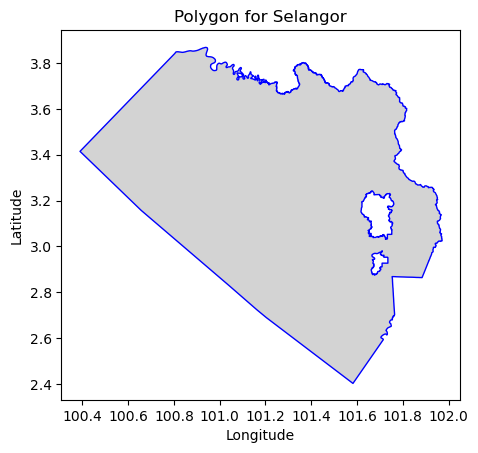

In [19]:
import osmnx as ox
import matplotlib.pyplot as plt

# Get state boundary
gdf = ox.geocode_to_gdf("Selangor, Malaysia")

# Plot the polygon
gdf.plot(edgecolor='blue', facecolor='lightgray')
plt.title("Polygon for Selangor")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


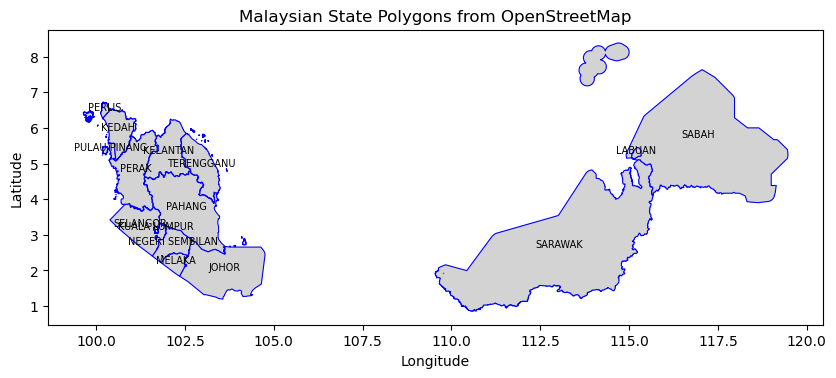

In [20]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt

# List of Malaysian states
states = [
    "KELANTAN", "NEGERI SEMBILAN", "PAHANG", "JOHOR", "PERLIS", "PULAU PINANG",
    "PERAK", "SELANGOR", "SARAWAK", "SABAH", "MELAKA", "KUALA LUMPUR",
    "TERENGGANU", "KEDAH", "LABUAN"
]

# Create empty GeoDataFrame
all_states_gdf = gpd.GeoDataFrame()

# Loop through states and fetch geometries
for state in states:
    gdf = ox.geocode_to_gdf(f"{state}, Malaysia")
    gdf["state_name"] = state
    all_states_gdf = pd.concat([all_states_gdf, gdf])

# Plot all polygons
fig, ax = plt.subplots(figsize=(10, 12))
all_states_gdf.plot(ax=ax, edgecolor='blue', facecolor='lightgray', linewidth=0.8)

# Annotate with state names
for _, row in all_states_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row["state_name"], xy=(centroid.x, centroid.y), fontsize=7, ha='center')

plt.title("Malaysian State Polygons from OpenStreetMap")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


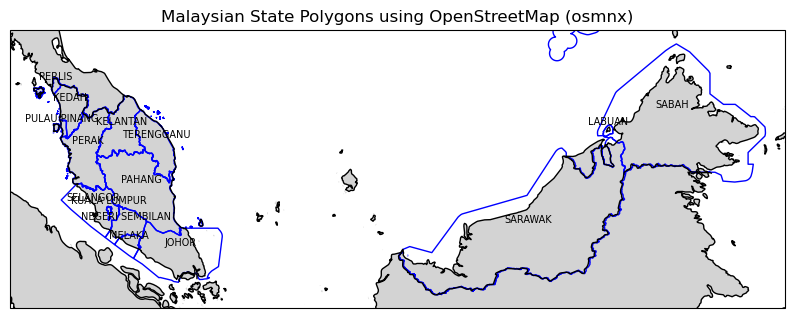

In [21]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import osmnx as ox
import geopandas as gpd

# Load all states
states = [
    "KELANTAN", "NEGERI SEMBILAN", "PAHANG", "JOHOR", "PERLIS", "PULAU PINANG",
    "PERAK", "SELANGOR", "SARAWAK", "SABAH", "MELAKA", "KUALA LUMPUR",
    "TERENGGANU", "KEDAH", "LABUAN"
]

all_states_gdf = gpd.GeoDataFrame()

for state in states:
    gdf = ox.geocode_to_gdf(f"{state}, Malaysia")
    gdf["state_name"] = state
    all_states_gdf = pd.concat([all_states_gdf, gdf])

# Match CRS to Cartopy (PlateCarree = EPSG:4326)
all_states_gdf = all_states_gdf.to_crs(epsg=4326)

# Start Plot
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([99, 120, 0.5, 8])
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Plot state polygons
all_states_gdf.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=1)

# Label states
for _, row in all_states_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y + 0.1, row["state_name"], fontsize=7, ha='center', va='bottom')

plt.title("Malaysian State Polygons using OpenStreetMap (osmnx)")
plt.show()


In [22]:
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point
import random

def generate_random_coords_from_state(state_name, n=10):
    """
    Generates n random (lat, lon) coordinates within the polygon of a Malaysian state.
    
    Args:
        state_name (str): Name of the Malaysian state (e.g., 'SELANGOR').
        n (int): Number of random points to generate.
    
    Returns:
        List of (latitude, longitude) tuples.
    """
    # Fetch state boundary using OSM
    gdf = ox.geocode_to_gdf(f"{state_name}, Malaysia")
    
    # Convert CRS to EPSG:4326 (WGS84)
    gdf = gdf.to_crs(epsg=4326)
    polygon = gdf.iloc[0].geometry

    # Generate points inside polygon
    coords = []
    minx, miny, maxx, maxy = polygon.bounds

    while len(coords) < n:
        point = Point(random.uniform(minx, maxx), random.uniform(miny, maxy))
        if polygon.contains(point):
            coords.append((point.y, point.x))  # (lat, lon)

    return coords


In [23]:
start_date = "2020-01-01"
end_date = "2020-01-07"
query_multiple_points(start_date, end_date, generate_random_coords_from_state("Kuala Lumpur", 30))

{'T2M': 25.035714285714285,
 'PRECTOTCORR': 2.637142857142857,
 'RH2M': 87.19428571428571}

In [24]:
start_date = "2001-01-01"
end_date = "2001-01-07"
query_multiple_points(start_date, end_date, generate_random_coords_from_state("Kuala Lumpur", 30))

{'T2M': 24.612857142857145,
 'PRECTOTCORR': 7.128571428571429,
 'RH2M': 87.64142857142858}

In [25]:
start_date = "2025-07-01"
end_date = "2025-07-07"
query_multiple_points(start_date, end_date, generate_random_coords_from_state("Kuala Lumpur", 30))

{'T2M': 25.95142857142857,
 'PRECTOTCORR': 5.215714285714285,
 'RH2M': 85.92857142857143}

In [26]:
state_bounds = {
    "KELANTAN": {
        "lat_min": 4.547555, "lat_max": 6.246167,
        "lon_min": 101.332765, "lon_max": 102.667123
    },
    "NEGERI SEMBILAN": {
        "lat_min": 2.391500, "lat_max": 3.288578,
        "lon_min": 101.702478, "lon_max": 102.700758
    },
    "PAHANG": {
        "lat_min": 2.459385, "lat_max": 4.781403,
        "lon_min": 101.330302, "lon_max": 104.227081
    },
    "JOHOR": {
        "lat_min": 1.210000, "lat_max": 2.950000,
        "lon_min": 102.440000, "lon_max": 104.600000
    },
    "PERLIS": {
        "lat_min": 6.257542, "lat_max": 6.725913,
        "lon_min": 100.120247, "lon_max": 100.373939
    },
    "PULAU PINANG": {
        "lat_min": 5.123466, "lat_max": 5.583133,
        "lon_min": 100.178719, "lon_max": 100.550664
    },
    "PERAK": {
        "lat_min": 3.666804, "lat_max": 5.934389,
        "lon_min": 100.374527, "lon_max": 101.752357
    },
    "SELANGOR": {
        "lat_min": 2.600389, "lat_max": 3.870599,
        "lon_min": 100.809608, "lon_max": 101.969572
    },
    "SARAWAK": {
        "lat_min": 0.853821, "lat_max": 4.995638,
        "lon_min": 109.538021, "lon_max": 115.678031
    },
    "SABAH": {
        "lat_min": 4.117483, "lat_max": 7.359583,
        "lon_min": 115.309738, "lon_max": 119.275444
    },
    "MELAKA": {
        "lat_min": 2.108722, "lat_max": 2.498729,
        "lon_min": 101.969553, "lon_max": 102.591980
    },
    "KUALA LUMPUR": {
        "lat_min": 3.038634, "lat_max": 3.243595,
        "lon_min": 101.611750, "lon_max": 101.757766
    },
    "TERENGGANU": {
        "lat_min": 3.884085, "lat_max": 5.947028,
        "lon_min": 102.377699, "lon_max": 103.697113
    },
    "KEDAH": {
        "lat_min": 5.080136, "lat_max": 6.538743,
        "lon_min": 99.640388, "lon_max": 101.127939
    },
    "LABUAN": {
        "lat_min": 5.221250, "lat_max": 5.397889,
        "lon_min": 115.118752, "lon_max": 115.267891
    }
}


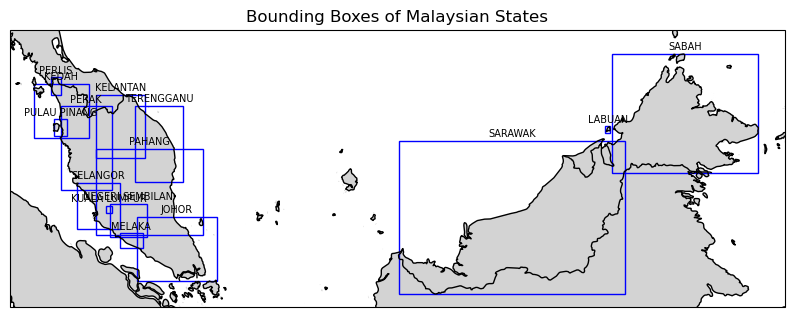

In [27]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([99, 120, 0.5, 8])
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, facecolor='lightgray')

for state, b in state_bounds.items():
    rect = plt.Rectangle((b['lon_min'], b['lat_min']),
                         b['lon_max'] - b['lon_min'],
                         b['lat_max'] - b['lat_min'],
                         edgecolor='blue', facecolor='none',
                         linewidth=1, label=state)
    ax.add_patch(rect)
    ax.text((b['lon_min'] + b['lon_max']) / 2, b['lat_max'] + 0.05,
            state, fontsize=7, ha='center', va='bottom')

plt.title("Bounding Boxes of Malaysian States")
plt.show()


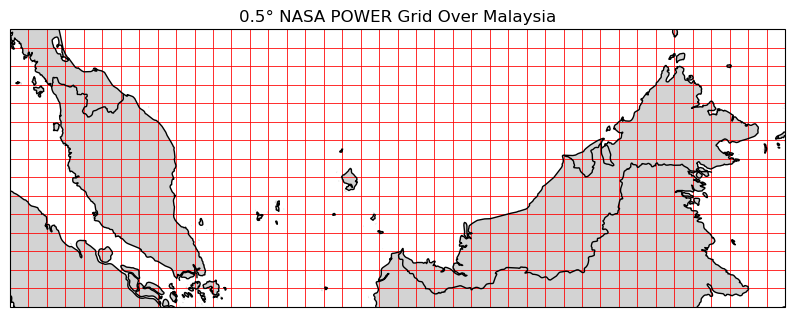

In [28]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import box
import geopandas as gpd

# Set Malaysia bounding box
lon_min, lon_max = 99, 120
lat_min, lat_max = 0.5, 8
grid_size = 0.5

# Create grid cells
grid_cells = []
for lon in range(int(lon_min * 2), int(lon_max * 2)):
    for lat in range(int(lat_min * 2), int(lat_max * 2)):
        cell = box(
            lon / 2, lat / 2,
            (lon + 1) / 2, (lat + 1) / 2
        )
        grid_cells.append(cell)

grid = gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:4326")

# Plot
fig, ax = plt.subplots(figsize=(10, 12), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Plot grid
grid.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.4)

plt.title("0.5° NASA POWER Grid Over Malaysia")
plt.show()


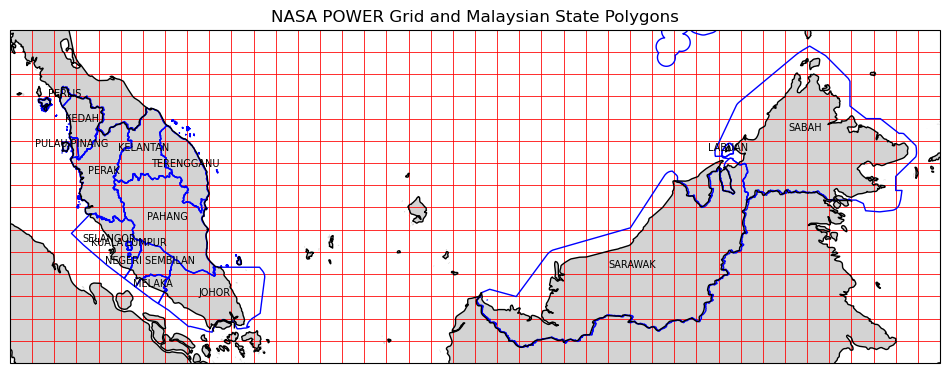

In [29]:
# Malaysia bounding box and grid parameters
lon_min, lon_max = 99, 120
lat_min, lat_max = 0.5, 8
grid_size = 0.5

# Create NASA POWER 0.5° grid
grid_cells = []
for lon in range(int(lon_min * 2), int(lon_max * 2)):
    for lat in range(int(lat_min * 2), int(lat_max * 2)):
        cell = box(lon / 2, lat / 2, (lon + 1) / 2, (lat + 1) / 2)
        grid_cells.append(cell)
grid = gpd.GeoDataFrame(geometry=grid_cells, crs="EPSG:4326")

# Malaysian states
states = [
    "KELANTAN", "NEGERI SEMBILAN", "PAHANG", "JOHOR", "PERLIS", "PULAU PINANG",
    "PERAK", "SELANGOR", "SARAWAK", "SABAH", "MELAKA", "KUALA LUMPUR",
    "TERENGGANU", "KEDAH", "LABUAN"
]

# Fetch state geometries from OSM
all_states_gdf = gpd.GeoDataFrame()
for state in states:
    gdf = ox.geocode_to_gdf(f"{state}, Malaysia")
    gdf["state_name"] = state
    all_states_gdf = pd.concat([all_states_gdf, gdf])

# Plot combined map
fig, ax = plt.subplots(figsize=(12, 14), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max])

ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Plot grid
grid.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.4)

# Plot Malaysian states
all_states_gdf.plot(ax=ax, edgecolor='blue', facecolor='none', linewidth=1)

# Annotate state names
for _, row in all_states_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row["state_name"], xy=(centroid.x, centroid.y), fontsize=7, ha='center')

plt.title("NASA POWER Grid and Malaysian State Polygons")
plt.show()


In [30]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def query_multiple_points_parallel(start, end, points):
    data_frames = []
    with ThreadPoolExecutor(max_workers=5) as executor:
        futures = [executor.submit(query_nasa_power, start, end, lat, lon) for lat, lon in points]
        for future in as_completed(futures):
            df = future.result()
            if not df.empty:
                data_frames.append(df)

    if data_frames:
        all_data = pd.concat(data_frames)
        return all_data.mean().to_dict()
    else:
        return None


In [31]:
results = []

for _, row in df.iterrows():
    print(_)
    state = row['state']
    if pd.notnull(state):
        coords = generate_random_coords_from_state(state, 10)
        summary = query_multiple_points(row['period_start'], row['period_end'], coords)
        if summary:
            results.append({
                "period_start": row['period_start'],
                "period_end": row['period_end'],
                "state": state,
                "year": row["year"],
                "T2M": summary.get("T2M"),
                "PRECTOTCORR": summary.get("PRECTOTCORR"),
                "RH2M": summary.get("RH2M")
            })
        

753
754
755
756
757
758
759
760
761
762
763
764
765
766
767
768
769
770
771
772
773
774
775
776
777
778
779
780
781
782
783
784
785
786
787
788
789
790
791
792
793
794
795
796
797
798
799
800
801
802
803
804
805
806
807
808
809
810
811
812
813
814
815
816
817
818
819
820
821
822
823
824
825
826
827
828
829
830
831
832
833
834
835
836
837
838
839
840
841
842
843
844
845
846
847
848
849
850
851
852
853
854
855
856
857
858
859
860
861
862
863
864
865
866
867
868
869
870
871
872
873
874
875
876
877
878
879
880
881
882
883
884
885
886
887
888
889
890
891
892
893
894
895
896
897
898
899
900
901
902
903
904
905
906
907
908
909
910
911
912
913
914
915
916
917
918
919
920
921
922
923
924
925
926
927
928
929
930
931
932
933
934
935
936
937
938
982
983
984
985
986
987
988
989
990
991
992
993
994
995
996
997
998
1012
1013
1014
1015
1016
1017
1018
1019
1020
1021
1022
1023
1024
1025
1026
1027
1028
1029
1030
1031
1032
1033
1034
1035
1036
1037
1038
1039
1040
1041
1042
1043
1044
1045
1046
1047
1048
104

In [38]:
climate_summary_df = pd.DataFrame(results)
df_merged = pd.merge(df, climate_summary_df, how="left", on=['state', 'year', 'period_start', 'period_end'])

In [46]:
df_merged.describe(include="all")

,country,state,location_full,period_start,period_end,year,dengue_cases,case_type,S_res,T_res,T2M,PRECTOTCORR,RH2M
count,1973,1328,1973,1973,1973,1973.000000,1973.000000,1973,1973,1973,1328.000000,1328.000000,1328.000000
unique,1,15,18,764,764,NaN,NaN,2,2,3,NaN,NaN,NaN
top,MALAYSIA,SELANGOR,MALAYSIA,2010-01-01,2010-12-31,NaN,NaN,Total,State,Month,NaN,NaN,NaN
freq,1973,131,645,25,25,NaN,NaN,1668,1328,1176,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2009.767359,1256.134313,NaN,NaN,NaN,26.107387,6.932712,85.381604
std,NaN,NaN,NaN,NaN,NaN,6.212931,5013.478600,NaN,NaN,NaN,1.122545,3.024505,3.178370
min,NaN,NaN,NaN,NaN,NaN,2001.000000,1.000000,NaN,NaN,NaN,22.661065,0.133226,72.884333
25%,NaN,NaN,NaN,NaN,NaN,2005.000000,109.000000,NaN,NaN,NaN,25.340650,5.093097,83.312498
50%,NaN,NaN,NaN,NaN,NaN,2009.000000,302.000000,NaN,NaN,NaN,26.158305,6.588324,85.599216
75%,NaN,NaN,NaN,NaN,NaN,2015.000000,1253.000000,NaN,NaN,NaN,26.962460,8.402182,87.653761


In [43]:
df_merged.head()

,country,state,location_full,period_start,period_end,year,dengue_cases,case_type,S_res,T_res,T2M,PRECTOTCORR,RH2M
0,MALAYSIA,SARAWAK,"MALAYSIA, SARAWAK",2001-01-01,2001-01-31,2001,52,Total,State,Month,24.463484,14.277871,90.645000
1,MALAYSIA,SELANGOR,"MALAYSIA, SELANGOR",2001-01-01,2001-01-31,2001,67,Total,State,Month,26.422065,10.371613,84.030452
2,MALAYSIA,JOHOR,"MALAYSIA, JOHOR",2001-01-01,2001-01-31,2001,114,Total,State,Month,25.918806,11.962871,88.090355
3,MALAYSIA,KELANTAN,"MALAYSIA, KELANTAN",2001-01-01,2001-01-31,2001,107,Total,State,Month,23.550581,7.564935,90.939000
4,MALAYSIA,NEGERI SEMBILAN,"MALAYSIA, NEGERI SEMBILAN",2001-01-01,2001-01-31,2001,190,Total,State,Month,25.413000,9.533871,87.505387


In [44]:
df_merged.tail()

,country,state,location_full,period_start,period_end,year,dengue_cases,case_type,S_res,T_res,T2M,PRECTOTCORR,RH2M
1968,MALAYSIA,PAHANG,"MALAYSIA, PAHANG",2013-01-01,2013-12-31,2013,725,Confirmed,State,Year,25.835800,7.726742,86.714011
1969,MALAYSIA,TERENGGANU,"MALAYSIA, TERENGGANU",2013-01-01,2013-12-31,2013,600,Confirmed,State,Year,26.202597,7.995189,84.995699
1970,MALAYSIA,NaN,MALAYSIA,2012-09-09,2012-09-15,2012,348,Total,National,Week,NaN,NaN,NaN
1971,MALAYSIA,NaN,MALAYSIA,2012-09-16,2012-09-22,2012,348,Total,National,Week,NaN,NaN,NaN
1972,MALAYSIA,NaN,MALAYSIA,2012-09-23,2012-09-29,2012,408,Total,National,Week,NaN,NaN,NaN


In [48]:
#df_merged.to_csv("temp.csv", index=False)

In [86]:
df_merged[df_merged['T_res'] == 'Year']

,country,state,location_full,period_start,period_end,year,dengue_cases,case_type,S_res,T_res,T2M,PRECTOTCORR,RH2M
10,MALAYSIA,NaN,MALAYSIA,2001-01-01,2001-12-31,2001,16368,Total,National,Year,NaN,NaN,NaN
131,MALAYSIA,NaN,MALAYSIA,2002-01-01,2002-12-31,2002,32767,Total,National,Year,NaN,NaN,NaN
317,MALAYSIA,NaN,MALAYSIA,2004-01-01,2004-12-31,2004,33895,Total,National,Year,NaN,NaN,NaN
438,MALAYSIA,NaN,MALAYSIA,2005-01-01,2005-12-31,2005,39686,Total,National,Year,NaN,NaN,NaN
559,MALAYSIA,NaN,MALAYSIA,2006-01-01,2006-12-31,2006,38556,Total,National,Year,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1965,MALAYSIA,NEGERI SEMBILAN,"MALAYSIA, NEGERI SEMBILAN",2013-01-01,2013-12-31,2013,1198,Confirmed,State,Year,26.369115,6.277479,84.739241
1966,MALAYSIA,PERAK,"MALAYSIA, PERAK",2013-01-01,2013-12-31,2013,2519,Confirmed,State,Year,25.789214,6.696504,84.387395
1967,MALAYSIA,SELANGOR,"MALAYSIA, SELANGOR",2013-01-01,2013-12-31,2013,23852,Confirmed,State,Year,27.324178,6.950071,81.245915
1968,MALAYSIA,PAHANG,"MALAYSIA, PAHANG",2013-01-01,2013-12-31,2013,725,Confirmed,State,Year,25.835800,7.726742,86.714011


In [87]:
# Filter to only 'Year' rows
year_df = df_merged[df_merged['T_res'] == 'Year']

# Count occurrences of each state
state_counts = year_df['state'].value_counts()

# Count occurrences of each year
year_counts = year_df['year'].value_counts()

print("State counts:\n", state_counts)
print("\nYear counts:\n", year_counts)

State counts:
 state
PERAK              11
PAHANG             11
MELAKA             11
NEGERI SEMBILAN    11
PERLIS             11
KUALA LUMPUR       11
SELANGOR           11
KELANTAN           11
TERENGGANU         11
PULAU PINANG       11
JOHOR              11
SABAH              11
SARAWAK            11
KEDAH              11
LABUAN             10
Name: count, dtype: int64

Year counts:
 year
2010    15
2011    15
2012    15
2013    15
2023    15
2018    15
2015    15
2014    15
2017    15
2016    15
2009    14
2001     1
2005     1
2004     1
2002     1
2008     1
2007     1
2006     1
2003     1
2019     1
Name: count, dtype: int64


In [49]:
population_df = pd.read_csv('population_state.csv')
population_df.head()

,state,date,sex,age,ethnicity,population
0,Johor,1970-01-01,both,overall,overall,1325.6
1,Johor,1970-01-01,both,0-4,overall,210.1
2,Johor,1970-01-01,both,5-9,overall,215.7
3,Johor,1970-01-01,both,10-14,overall,192.2
4,Johor,1970-01-01,both,15-19,overall,152.8


In [50]:
population_df.shape

(263679, 6)

In [51]:
population_df.describe(include="all")

,state,date,sex,age,ethnicity,population
count,263679,263679,263679,263679,263679,263679.000000
unique,16,56,3,21,9,NaN
top,Johor,2018-01-01,both,overall,overall,NaN
freq,17415,6384,87893,14061,45393,NaN
mean,NaN,NaN,NaN,NaN,NaN,36.029511
std,NaN,NaN,NaN,NaN,NaN,157.116216
min,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,0.300000
50%,NaN,NaN,NaN,NaN,NaN,3.300000
75%,NaN,NaN,NaN,NaN,NaN,21.900000


In [83]:
population_df[population_df['state'].isna()]


,state,date,sex,age,ethnicity,population,year
825,NaN,1981-01-01,both,70-74,overall,18.2,1981
826,NaN,1981-01-01,both,70-74,bumi,7.4,1981
827,NaN,1981-01-01,both,70-74,chinese,9.6,1981
828,NaN,1981-01-01,both,70-74,indian,1.2,1981
829,NaN,1981-01-01,both,70-74,other,0.1,1981
...,...,...,...,...,...,...,...
263674,NaN,2025-01-01,male,85+,bumi_other,0.0,2025
263675,NaN,2025-01-01,male,85+,chinese,0.0,2025
263676,NaN,2025-01-01,male,85+,indian,0.0,2025
263677,NaN,2025-01-01,male,85+,other_citizen,0.0,2025


In [68]:
df_merged['state'] = df_merged['state'].str.upper().str.strip()
population_df['state'] = pop_agg['state'].str.upper().str.strip()

In [69]:
# Convert to datetime and extract year
population_df['date'] = pd.to_datetime(population_df['date'])
population_df['year'] = population_df['date'].dt.year

In [70]:
population_filtered = population_df[
    (population_df["sex"] == "both") &
    (population_df["age"] == "overall") &
    (population_df["ethnicity"] == "overall")
]

population_filtered.sample(10)

,state,date,sex,age,ethnicity,population,year
116718,NaN,2013-01-01,both,overall,overall,2447.2,2013
149553,NaN,2008-01-01,both,overall,overall,1531.3,2008
6243,NaN,1998-01-01,both,overall,overall,2631.7,1998
139704,NaN,1978-01-01,both,overall,overall,925.7,1978
258891,NaN,2014-01-01,both,overall,overall,80.9,2014
2910,NaN,1989-01-01,both,overall,overall,2085.5,1989
207384,NaN,2022-01-01,both,overall,overall,7050.3,2022
122049,NaN,1973-01-01,both,overall,overall,131.7,1973
240936,NaN,2020-01-01,both,overall,overall,1982.1,2020
216420,NaN,2001-01-01,both,overall,overall,920.0,2001


In [71]:
df_merged_pop = df_merged.merge(population_filtered, on=['state', 'year'], how='left')

In [72]:
df_merged_pop[df_merged_pop['T_res'] == 'Year'].sample(50)

,country,state,location_full,period_start,period_end,year,dengue_cases,case_type,S_res,T_res,T2M,PRECTOTCORR,RH2M,date,sex,age,ethnicity,population
1019,MALAYSIA,MELAKA,"MALAYSIA, MELAKA",2009-01-01,2009-12-31,2009,769,Confirmed,State,Year,27.267312,6.180134,82.597781,NaT,NaN,NaN,NaN,NaN
353,MALAYSIA,NaN,MALAYSIA,2004-01-01,2004-12-31,2004,33895,Total,National,Year,NaN,NaN,NaN,2004-01-01,both,overall,overall,1436.6
1253,MALAYSIA,LABUAN,"MALAYSIA, LABUAN",2011-01-01,2011-12-31,2011,16,Confirmed,State,Year,27.298093,8.234463,82.110827,NaT,NaN,NaN,NaN,NaN
5746,MALAYSIA,PULAU PINANG,"MALAYSIA, PULAU PINANG",2017-01-01,2017-12-31,2017,2681,Confirmed,State,Year,27.014282,8.401899,82.609899,NaT,NaN,NaN,NaN,NaN
11564,MALAYSIA,PULAU PINANG,"MALAYSIA, PULAU PINANG",2013-01-01,2013-12-31,2013,1053,Confirmed,State,Year,26.785803,6.311710,82.112370,NaT,NaN,NaN,NaN,NaN
1243,MALAYSIA,JOHOR,"MALAYSIA, JOHOR",2011-01-01,2011-12-31,2011,1583,Confirmed,State,Year,26.507449,7.432929,86.157214,NaT,NaN,NaN,NaN,NaN
11565,MALAYSIA,LABUAN,"MALAYSIA, LABUAN",2013-01-01,2013-12-31,2013,14,Confirmed,State,Year,27.775995,7.811392,81.278395,NaT,NaN,NaN,NaN,NaN
629,MALAYSIA,NaN,MALAYSIA,2006-01-01,2006-12-31,2006,38556,Total,National,Year,NaN,NaN,NaN,2006-01-01,both,overall,overall,82.0
6615,MALAYSIA,JOHOR,"MALAYSIA, JOHOR",2018-01-01,2018-12-31,2018,7932,Total,State,Year,27.432008,6.109016,83.039567,NaT,NaN,NaN,NaN,NaN
4906,MALAYSIA,PULAU PINANG,"MALAYSIA, PULAU PINANG",2016-01-01,2016-12-31,2016,2576,Confirmed,State,Year,27.067036,6.172902,81.604699,NaT,NaN,NaN,NaN,NaN
